# 04 — SHAP Explainability

Explains the winning model's predictions with SHAP (SHapley Additive exPlanations),
producing a **real, data-driven** version of the illustrative "Soil 30% / History 45% /
Rainfall 25%" contribution split shown on the live component site's Mechanism section —
computed here from the actual synthetic model instead of hand-picked for illustration.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from landslide_toy import viz

viz.set_style()
df = pd.read_csv(ROOT / "data" / "synthetic" / "nuwara_eliya_synthetic_sites.csv")
bundle = joblib.load(ROOT / "outputs" / "models" / "best_model.joblib")
model = bundle["model"]
print("Explaining:", bundle["model_name"], "on", bundle["feature_set_name"])


Explaining: XGBoost on Set A (soil+rainfall+history)


In [2]:
def encode(frame, categorical_cols, numeric_cols):
    dummies = pd.get_dummies(frame[categorical_cols].astype(str), prefix=categorical_cols)
    numeric = frame[numeric_cols].reset_index(drop=True)
    return pd.concat([numeric, dummies.reset_index(drop=True)], axis=1)


X_full = encode(df, bundle["categorical_cols"], bundle["numeric_cols"])
X_full = X_full.reindex(columns=bundle["feature_columns"], fill_value=0)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_full)
if isinstance(shap_values, list):
    shap_values = shap_values[1]  # positive-class SHAP values for binary classifiers that return a list
shap_values = np.asarray(shap_values)
print("SHAP values shape:", shap_values.shape)


SHAP values shape: (450, 13)


## 1. Global feature importance

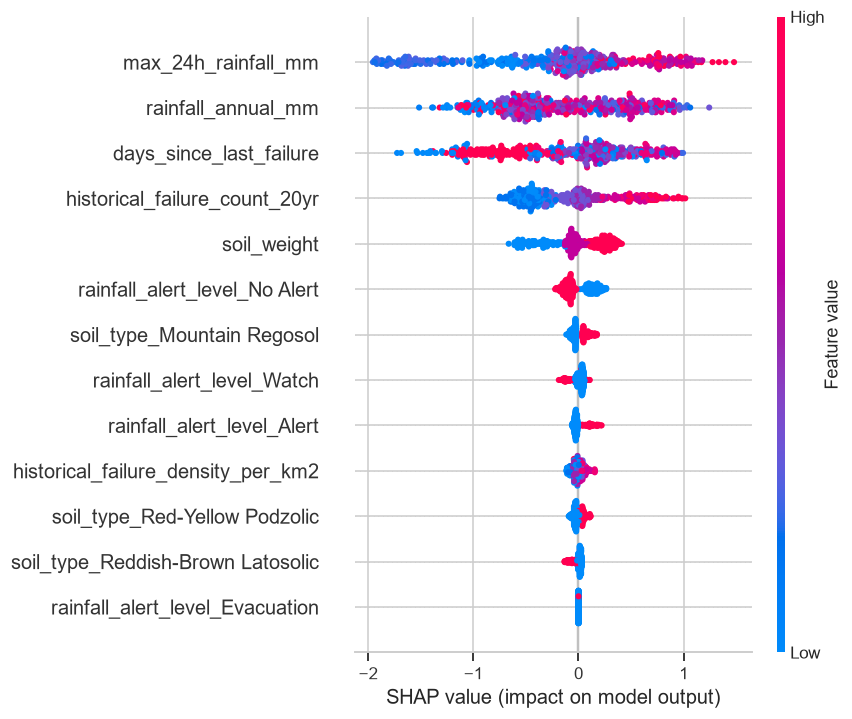

In [3]:
shap.summary_plot(shap_values, X_full, show=False)
plt.tight_layout()
plt.show()


## 2. Grouping columns back into Soil / Rainfall / History (or Slope)

Each categorical factor was one-hot encoded for modeling (e.g. `soil_type_Red-Yellow
Podzolic`). To produce the percentage-breakdown-by-cause chart the site already shows
illustratively, SHAP values are summed back to the original factor group.

In [4]:
def factor_group(col):
    if col.startswith("soil_"):
        return "Soil"
    if col.startswith("rainfall_") or col in ("rainfall_annual_mm", "max_24h_rainfall_mm"):
        return "Rainfall"
    if col.startswith("historical_") or col == "days_since_last_failure":
        return "History"
    if col.startswith("slope_"):
        return "Slope"
    return "Other"


groups = pd.Series([factor_group(c) for c in X_full.columns], index=X_full.columns)
print(groups.value_counts())


Rainfall    6
Soil        4
History     3
Name: count, dtype: int64


## 3. Global percentage breakdown by cause

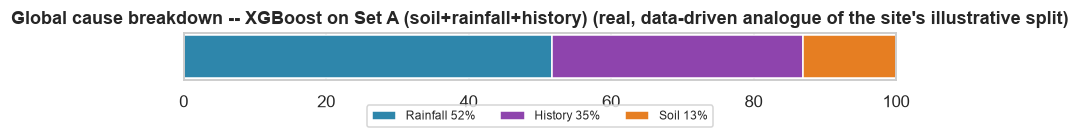

Rainfall    51.700001
History     35.299999
Soil        13.000000
dtype: float32

In [5]:
abs_shap = np.abs(shap_values)
group_importance = pd.DataFrame(abs_shap, columns=X_full.columns).T.groupby(groups).sum().T.mean()
group_pct = (group_importance / group_importance.sum() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 1.8))
left = 0
palette = {"Soil": "#E67E22", "Rainfall": "#2E86AB", "History": "#8E44AD", "Slope": "#27AE60"}
for group, pct in group_pct.items():
    ax.barh(0, pct, left=left, color=palette.get(group, "#95A5A6"), label=f"{group} {pct:.0f}%")
    left += pct
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_title(f"Global cause breakdown -- {bundle['model_name']} on {bundle['feature_set_name']} "
             f"(real, data-driven analogue of the site's illustrative split)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.4), ncol=len(group_pct), fontsize=8)
plt.tight_layout()
plt.show()

group_pct.round(1)


## 4. Per-site local breakdown for example cases

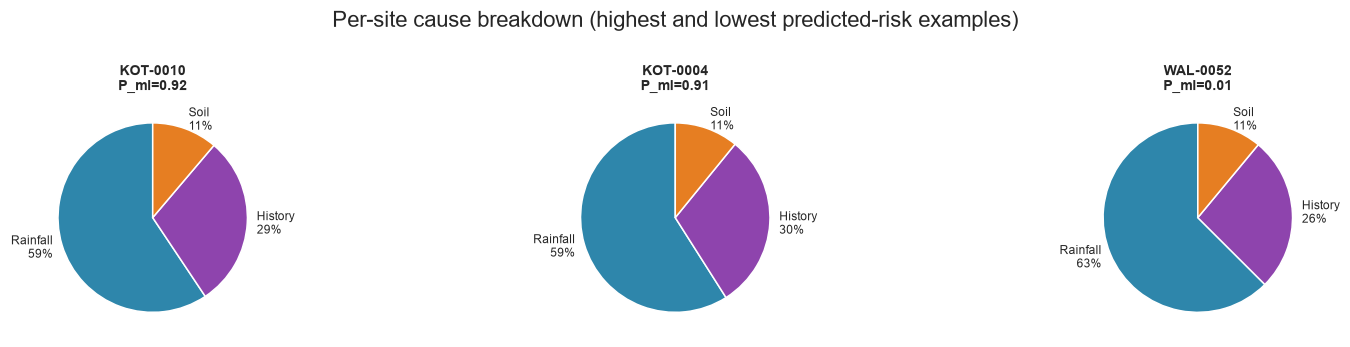

In [6]:
top_idx = np.argsort(-model.predict_proba(X_full)[:, 1])[:2]
low_idx = np.argsort(model.predict_proba(X_full)[:, 1])[:1]
example_positions = list(top_idx) + list(low_idx)

fig, axes = plt.subplots(1, len(example_positions), figsize=(5 * len(example_positions), 3.2))
if len(example_positions) == 1:
    axes = [axes]

for ax, pos in zip(axes, example_positions):
    site_shap = pd.Series(shap_values[pos], index=X_full.columns)
    local_group = site_shap.abs().groupby(groups).sum()
    local_pct = (local_group / local_group.sum() * 100).reindex(group_pct.index).fillna(0)
    ax.pie(local_pct, labels=[f"{g}\n{p:.0f}%" for g, p in local_pct.items()],
           colors=[palette.get(g, "#95A5A6") for g in local_pct.index],
           startangle=90, textprops={"fontsize": 8})
    site_id = df.iloc[pos]["site_id"]
    p_val = model.predict_proba(X_full)[pos, 1]
    ax.set_title(f"{site_id}\nP_ml={p_val:.2f}", fontsize=9)

plt.suptitle("Per-site cause breakdown (highest and lowest predicted-risk examples)")
plt.tight_layout()
plt.show()


## 5. Interpretation

- The global breakdown above is the **real analogue**, computed from this synthetic
  model, of the illustrative Soil/History/Rainfall split shown on the live site's
  Mechanism section — it will change once the pipeline is re-run on real data or if
  Feature Set B (soil+rainfall+slope) turns out to be the winning combination in
  notebook 02, in which case "History" is replaced by "Slope" here.
- Per-site local breakdowns are what would power the "exact percentage breakdown of
  causes" feature described in the original research objective (Explainable Micro-Level
  Terrain Failures) — this notebook demonstrates the mechanism end-to-end on synthetic
  data, ready to be pointed at real per-site records.

This closes the 4-notebook pipeline: `01` generates data, `02` picks the more predictive
feature set fairly, `03` turns its output into an interpretable severity scale, and `04`
explains individual predictions.